<a href="https://colab.research.google.com/github/venkateshannabathina/icanseeyou_isro/blob/main/notebooks/04_bls_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install -q lightkurve astropy

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

from astropy.timeseries import BoxLeastSquares

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
search_result = lk.search_lightcurve(
    "TIC 25155310",
    mission="TESS"
)

lc = search_result[0].download()

lc_clean = (
    lc.remove_nans()
      .remove_outliers(sigma=5)
      .flatten(window_length=401)
      .normalize()
)

In [14]:
time = lc_clean.time.value
flux = lc_clean.flux.value

In [17]:
bls = BoxLeastSquares(time, flux)

periods = np.linspace(0.5, 15, 10000)

durations = np.linspace(0.01, 0.2, 20)

results = bls.power(periods, durations)

In [18]:
best = np.argmax(results.power)

best_period = results.period[best]
best_duration = results.duration[best]
best_depth = results.depth[best]

print(f"Period: {best_period:.4f} days")
print(f"Duration: {best_duration:.4f} days")
print(f"Depth: {best_depth:.6f}")

Period: 3.2886 days
Duration: 0.1400 days
Depth: 0.002298


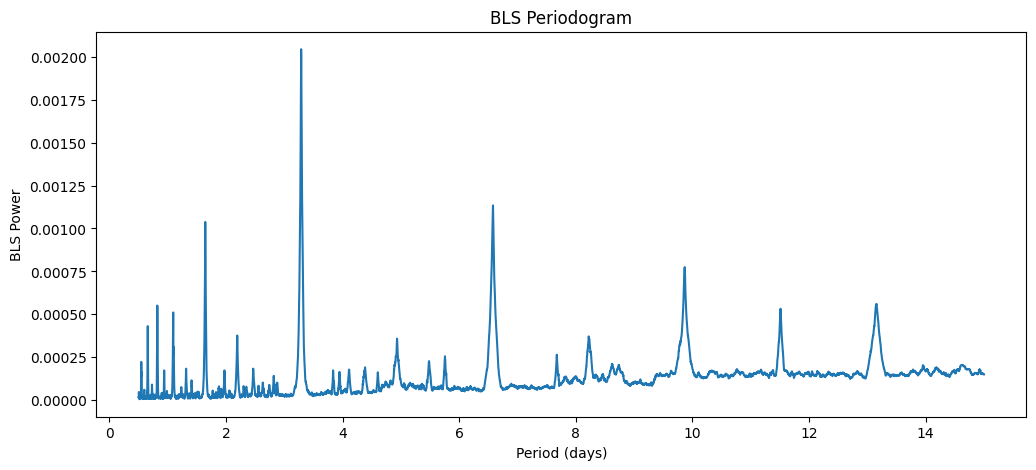

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(results.period, results.power)

plt.xlabel("Period (days)")
plt.ylabel("BLS Power")
plt.title("BLS Periodogram")

plt.show()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

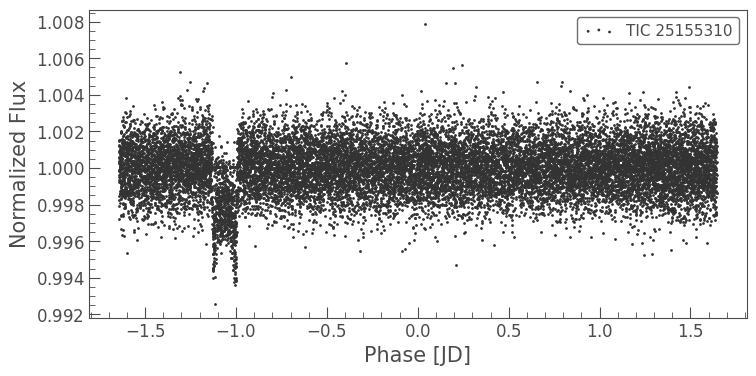

In [20]:
folded = lc_clean.fold(period=best_period)

folded.scatter()